In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/opt/homebrew/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
def f(X):
    X = np.atleast_2d(X)
    return 0.5 * X[:, 0] + np.sin(X[:, 1]) - 0.3 * X[:, 2] ** 2

def knn_predict(X, Y, x0, k):
    dist = np.sqrt(np.sum((X-x0) ** 2, axis = 1))
    return Y[np.argsort(dist)[:k]].mean()

In [4]:
x0 = np.array([0.5, 0.7, 1.0])
rng = np.random.default_rng(42)
n = 400
X = rng.standard_normal((n,3))
Y = f(X) + rng.normal(0, 0.1, n)

In [5]:
ks = np.arange(1, 30, 2)
preds = [knn_predict(X, Y, x0, k) for k in ks]
print(
    pd.DataFrame({"k": ks, "x_0 prediction": preds})
        .style
        .hide(axis="index")
        .to_typst()
)

#table(
  columns: 3,
  [], [k], [x_0 prediction],

  [], [1], [0.886111],
  [], [3], [0.780870],
  [], [5], [0.614012],
  [], [7], [0.529068],
  [], [9], [0.557340],
  [], [11], [0.598498],
  [], [13], [0.623486],
  [], [15], [0.569935],
  [], [17], [0.522069],
  [], [19], [0.534670],
  [], [21], [0.566064],
  [], [23], [0.539307],
  [], [25], [0.494147],
  [], [27], [0.494316],
  [], [29], [0.520445],
)


In [6]:
runs = []
rng = np.random.default_rng(42)
for i in range(200):
    X = rng.standard_normal((n, 3))
    Y = f(X) + rng.normal(0, 0.1, n)
    ks = np.arange(1, 30, 2)
    preds = [knn_predict(X, Y, x0, k) for k in ks]
    runs.append(pd.DataFrame({"run": i, "k": ks, "x_0 prediction": preds}))

results = pd.concat(runs, ignore_index=True).pivot(index="k", columns="run", values="x_0 prediction")

#table(
  columns: 6,
  [], [bias], [variance], [mse], [bias^2], [bias^2 + variance],
  [k], [], [], [], [], [],

  [1], [-0.030036], [0.043352], [0.044255], [0.000902], [0.044255],
  [3], [-0.032048], [0.019232], [0.020259], [0.001027], [0.020259],
  [5], [-0.046025], [0.014979], [0.017097], [0.002118], [0.017097],
  [7], [-0.049777], [0.012150], [0.014628], [0.002478], [0.014628],
  [9], [-0.058487], [0.011749], [0.015169], [0.003421], [0.015169],
  [11], [-0.063704], [0.010078], [0.014136], [0.004058], [0.014136],
  [13], [-0.070518], [0.009857], [0.014830], [0.004973], [0.014830],
  [15], [-0.075634], [0.008654], [0.014374], [0.005720], [0.014374],
  [17], [-0.087371], [0.007585], [0.015219], [0.007634], [0.015219],
  [19], [-0.092775], [0.007667], [0.016274], [0.008607], [0.016274],
  [21], [-0.095844], [0.007439], [0.016626], [0.009186], [0.016626],
  [23], [-0.102150], [0.007036], [0.017470], [0.010435], [0.017470],
  [25], [-0.107872], [0.006666], [0.018302], [0.011636], [0.018

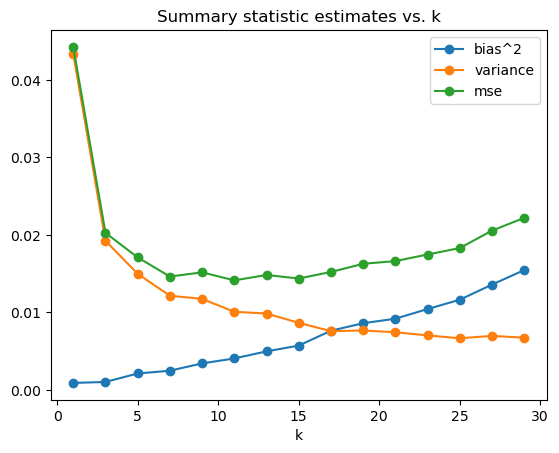

In [7]:
f_x0 = float(f(x0)[0])

summary = pd.DataFrame({
    "bias": results.mean(axis = 1) - f_x0,
    "variance": results.var(axis = 1, ddof = 0),
    "mse": ((results - f_x0) ** 2).mean(axis = 1)
})
summary["bias^2"] = summary["bias"] ** 2
summary["bias^2 + variance"] = summary["bias^2"] + summary["variance"]

print(summary.style.to_typst())

summary[["bias^2", "variance", "mse"]].plot(marker="o", title="Summary statistic estimates vs. k")
plt.savefig("q1.png", dpi=200)
plt.show()

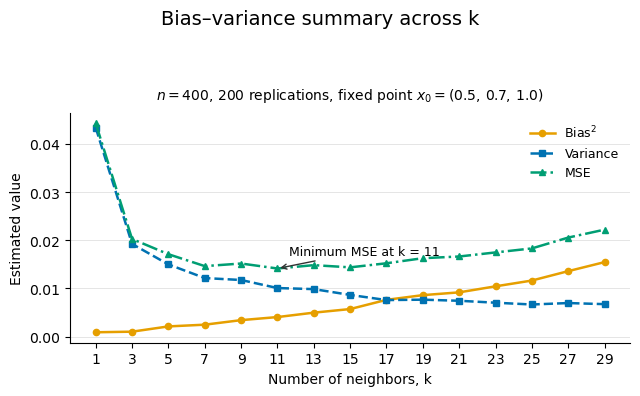

In [8]:
# ...existing code...

fig, ax = plt.subplots(figsize=(6.5, 4))

plot_specs = [
    ("bias^2", r"Bias$^2$", "#E69F00", "o", "-"),
    ("variance", "Variance", "#0072B2", "s", "--"),
    ("mse", "MSE", "#009E73", "^", "-."),
]

for column, label, color, marker, linestyle in plot_specs:
    ax.plot(
        summary.index,
        summary[column],
        label=label,
        color=color,
        marker=marker,
        linestyle=linestyle,
        linewidth=1.8,
        markersize=4.5,
    )

min_k = summary["mse"].idxmin()
min_mse = summary.loc[min_k, "mse"]
ax.annotate(
    f"Minimum MSE at k = {min_k}",
    xy=(min_k, min_mse),
    xytext=(8, 10),
    textcoords="offset points",
    fontsize=9,
    arrowprops={"arrowstyle": "->", "color": "#333333", "lw": 1},
)

fig.suptitle("Bias–variance summary across k", fontsize=14, y=0.98)
ax.set_title(
    r"$n=400$, 200 replications, fixed point $x_0=(0.5,\,0.7,\,1.0)$",
    fontsize=10,
    pad=10,
)
ax.set_xlabel("Number of neighbors, k", fontsize=10)
ax.set_ylabel("Estimated value", fontsize=10)
ax.set_xticks(summary.index)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=9)

fig.tight_layout(rect=[0, 0, 1, 0.91])
fig.savefig("q1_formatted.png", dpi=250, bbox_inches="tight")
plt.show()

# ...existing code...